This notebook generates the set of full resolution unwrapped interferograms that are needed to estimate displacement time series and invert for displacement rates. I unwrap the intergerograms by first multilooking them (to smooth them for easier unwrapping), unwrap them with SNAPHU (Chen and Zebker, 2002), then I add back in the noise term that I removed with the multilooking. 
<br> <br>
The method used here is described fully in Paschall and Lohman (2025): "Pixel-to-Pixel Displacement Rate Heterogeneity and Effects on InSAR Time Series Near Laguna Salada in Baja California, Mexico." 
<br><br>
Use the "earthscope_insar" conda environment as the Python kernel for this and all subsequent notebooks.
***

In [1]:
# load the necessary packages
import os,sys
import glob
import pandas as pd
import math
from osgeo import gdal
import numpy as np
from array import array
from scipy  import signal
import matplotlib.pyplot as plt
from scipy.stats import gaussian_kde
from scipy.ndimage import gaussian_filter

import isce, isceobj
from contrib.Snaphu.Snaphu import Snaphu

import shutil
from imageMath import IML
%matplotlib  widget

In [4]:
# define working directory, crop directory, and SLC directory 
workdir = '/data/ocp4/SuperstitionHills/Data_and_Figs/' 
cropdir = 'cropped_20000_2475_9000_1575/' 
SLCdir = 'VV/merged/SLC/'

# size of SLCs
x1 = 0; y1= 0    #values are 0 if interferogram has already been cropped
dx= 9000; dy=1575

# print('range: '+str(dx))
# print('azimuth: '+str(dy))
# print('total number of pixels: '+str(dx*dy))

# How much do we want to spatially filter/smooth so that SNAPHU can successfully unwrap the interferograms? 
alooks=4
rlooks=20

# define directory where you want to save all your filtered and "unfiltered" unwrapped interferograms 
fullResdir = '/data/ocp4/SuperstitionHills/Data_and_Figs/fullRes_unwrapped_interferograms/'
# make sure this is separate from where the pre-made interferograms (with run_all.ipynb/runStuffVX) sit - those are multilooked.
filtUnwrappedDir = fullResdir + 'filt_unwrapped/' # may not need these in the future, is an intermediate step. But nice for plotting.
unfiltUnwrappedDir = fullResdir + 'unfilt_unwrapped/'

filtDir = './temp_filt/' # may not need these in the future, is an intermediate step. But nice for plotting.
unfiltUnwrappedDir = './temp_unfilt_unwrapped/'

In [3]:
# load in dates
dates = [os.path.basename(x) for x in glob.glob(workdir+cropdir+SLCdir+'*')]
dates = sorted(dates)
nd = len(dates); numIgrams = nd - 1

print(dates)
print(str(numIgrams) + ' interferograms to unwrap.')

['20180610', '20180622', '20180704', '20180716', '20180728', '20180809', '20180821', '20180902', '20180914', '20180926', '20181008', '20181020', '20181101', '20181113', '20181125', '20181207', '20181219', '20181231', '20190112', '20190124', '20190205', '20190217', '20190301', '20190313', '20190325', '20190406', '20190430', '20190512', '20190524', '20190605', '20190617', '20190629', '20190711', '20190723', '20190804', '20190816', '20190822', '20190828', '20190903', '20190909', '20190915', '20190921', '20190927', '20191003', '20191009', '20191015', '20191021', '20191027', '20191102', '20191108', '20191114', '20191120', '20191126', '20191202', '20191208', '20191214', '20191220', '20191226', '20200101', '20200107', '20200113', '20200119', '20200125', '20200131', '20200206', '20200212', '20200218', '20200224', '20200301', '20200307', '20200313', '20200319', '20200325', '20200331', '20200406', '20200412', '20200418', '20200430', '20200506', '20200512', '20200518', '20200524', '20200530', '20

In [ ]:
# unwrap sequential interferograms: loop over the dates
#   load in the SLCs, create the full resolution interferogram, 
#   multilook/filter/smooth it, put it through SNAPHU, 
#   do the math to add back in the noise ("unfilter" it)
#   then save it 

# set the driver first, only do once.
driver=gdal.GetDriverByName('ISCE')

# loop over the interferograms and unwrap them
for i in range(1):   # numIgrams  
    # define dates
    date1 = dates[i]
    date2 = dates[i + 1]
    
    # load in SLCs
    ds = gdal.Open(workdir+cropdir+SLCdir+date1+"/"+date1+".slc.full", gdal.GA_ReadOnly)
    slc1 = ds.GetRasterBand(1).ReadAsArray(x1,y1,dx,dy)
    print('SLC 1 loaded.')
    ds = gdal.Open(workdir+cropdir+SLCdir+date2+"/"+date2+".slc.full", gdal.GA_ReadOnly)
    slc2 = ds.GetRasterBand(1).ReadAsArray(x1,y1,dx,dy)
    print('SLC 2 loaded.')
    # make the interferogram 
    intTemp = (slc1*np.conj(slc2))

    # FILTER THE IGRAM
    # read in two SLCs, make igram, filter it, output it as a file
    # Must filter real and imaginary parts independently then recombine them. 
    s1=slc1*np.conj(slc1)
    s2=slc2*np.conj(slc2)
    a1r=gaussian_filter(np.real(s1), sigma=[alooks/4,rlooks/4])
    a1i=gaussian_filter(np.imag(s1), sigma=[alooks/4,rlooks/4])
    a2r=gaussian_filter(np.real(s2), sigma=[alooks/4,rlooks/4])
    a2i=gaussian_filter(np.imag(s2), sigma=[alooks/4,rlooks/4])
    a1 = a1r+1j*a1i
    a2 = a2r+1j*a2i
    filtimager=gaussian_filter(np.real(intTemp), sigma=[alooks/4,rlooks/4])
    filtimagei=gaussian_filter(np.imag(intTemp), sigma=[alooks/4,rlooks/4])
    filt_intTemp = filtimager+1j*filtimagei
    scaler= np.sqrt(a1*a2)
    filt_intTemp = filt_intTemp/scaler

    # save the filtered wrapped file 
    colds = driver.Create(filtDir+'filt_igram_temp.r4',dx,dy,1,gdal.GDT_Float32)
    colds.GetRasterBand(1).WriteArray(np.angle(filt_intTemp))
    colds=None

    print('Filt igram saved for dates: ' + date1 + '-' + date2)
    # NOTE: 
    # this print statement may not appear until AFTER SNAPHU is done. Don't be concerned if this step appears
    # to be taking too long - SNAPHU just delays the print statement for some reason. 
    
    # UNWRAP the filtered interferogram

    # this is what we want the SNAPHU output file to be named. 
    outfile = filtDir+date1+'_'+date2+'_filt.unw'
    # this is the file we put into SNAPHU 
    inputFilename = filtDir+'filt_igram_temp.r4'

    # try using SNAPHU in the loop
    snaphu = Snaphu()
    snaphu.setInput(inputFilename)
    snaphu.setOutput(outfile)
    snaphu.setWidth(dx) 
    snaphu.setCostMode('DEFO') # try SMOOTH, was DEFO to start
    snaphu.setEarthRadius(6356236.24233467)
    snaphu.setWavelength(0.0562356424)
    snaphu.setAltitude(788151.7928135)
    snaphu.setCorFileFormat('FLOAT_DATA')
    snaphu.setIntFileFormat('FLOAT_DATA')
    snaphu.setUnwFileFormat('FLOAT_DATA')
    print("Preparing")
    snaphu.prepare()
    snaphu.unwrap()

    # we need an .xml file for the unwrapped igram, so copy one from a file with the exact dimensions
    copyThisFile = filtDir+'filt_igram_temp.r4.xml'
    putItHere = outfile+'.xml'

    # copy the file
    shutil.copy(copyThisFile,putItHere)
    
    # "UNFILTER" THE UNWRAPPED IGRAM

    # loading in the unwrapped igram that was just generated (make sure that you are calling the correct file)
    f1 = gdal.Open(outfile, gdal.GA_ReadOnly)  
    unwr_filt_igram = f1.ReadAsArray()
    f1 = None

    # generate full resolution ("unfiltered") unwrapped interferogram
    unwr_full_res = np.angle(np.exp(1j*np.angle(intTemp)) * np.conj(np.exp(1j*np.angle(filt_intTemp)))) + unwr_filt_igram
    print('Igram unfiltered.')

    # save it 
    colds = driver.Create(unfiltUnwrappedDir+date1+'_'+date2+'_'+'unfilt.unw',dx,dy,1,gdal.GDT_Float32)
    colds.GetRasterBand(1).WriteArray((unwr_full_res))
    colds=None
    print('Unfiltered, unwrapped igram for '+date1+'-'+date2+' saved.')
    

SLC 1 loaded.
SLC 2 loaded.
Filt igram saved for dates: 20180610-20180622
Preparing

snaphu v1.4.2
Reading wrapped phase from file ./temp_filt/filt_igram_temp.r4
No weight file specified.  Assuming uniform weights
No correlation file specified.  Assuming correlation = 0.01
Calculating deformation-mode cost parameters
Initializing flows with MST algorithm
Running nonlinear network flow optimizer
Maximum flow on network: 5
Flow increment: 1  (Total improvements: 0)
Growing connected component mask
Writing connected components to file ./temp_filt/20180610_20180622_filt.unw.conncomp
Maximum flow on network: 1
Total solution cost: 13564575
Integrating phase
Writing output to file ./temp_filt/20180610_20180622_filt.unw
Igram unfiltered.
Unfiltered, unwrapped igram for 20180610-20180622 saved.


In [9]:
# This tests if the unwrapping was successful. Load in the filtered, wrapped igram 
# and the unfiltered, unwrapped igram. Did it work? 

f1 = gdal.Open(filtDir+'filt_igram_temp.r4', gdal.GA_ReadOnly)
filt_igram_loaded = f1.ReadAsArray()
f1 = None
f1 = gdal.Open(filtDir+date1+'_'+ date2+ '_filt.unw', gdal.GA_ReadOnly)
unwr_filt_igram_loaded = f1.ReadAsArray()
f1 = None
# you can define specific date1 and date2 or leave this as the most recently-defined ones from the last loop iteration
f1 = gdal.Open(unfiltUnwrappedDir+date1+'_'+ date2+ '_unfilt.unw', gdal.GA_ReadOnly)
unwr_unfilt_igram_loaded = f1.ReadAsArray()
f1 = None

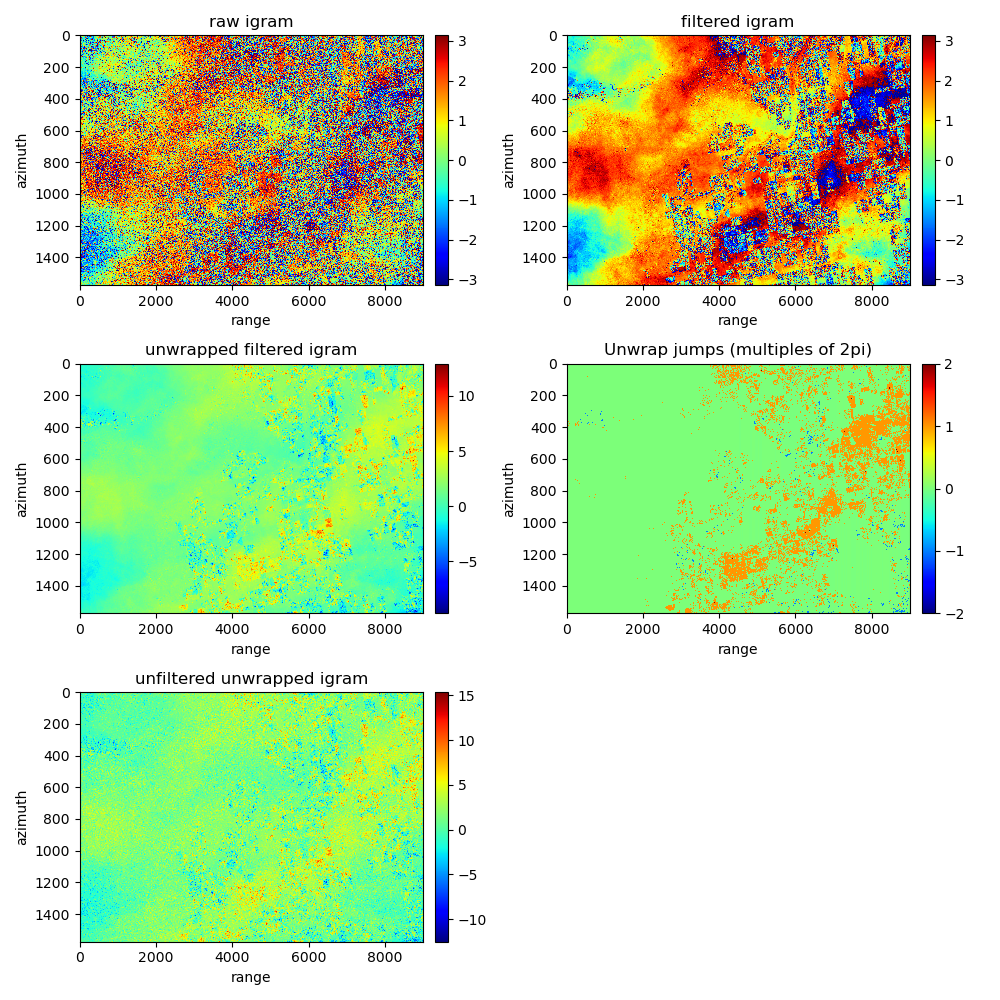

In [ ]:
# now plot all versions for one interferogram 
# see if they look correct! 

fig = plt.figure(figsize=(10,10),tight_layout='TRUE')
plt.subplot(3,2,1)
plt.imshow(np.fliplr(np.angle(intTemp)),aspect='auto',interpolation='nearest')
plt.colorbar(orientation='vertical',pad=0.03); plt.set_cmap('jet')
plt.title('raw igram'); plt.xlabel('range'); plt.ylabel('azimuth')
# This subplot relies on having just run the loop. 
#   Won't plot if you only ran the above code cell to load in the filt/unfilt wrapped/unwrapped igrams. 

plt.subplot(3,2,2)
plt.imshow(np.fliplr(filt_igram_loaded),aspect='auto',interpolation='nearest')
plt.colorbar(orientation='vertical',pad=0.03); plt.set_cmap('jet')
plt.title('filtered igram'); plt.xlabel('range'); plt.ylabel('azimuth')

plt.subplot(3,2,3)
plt.imshow(np.fliplr(unwr_filt_igram_loaded),aspect='auto',interpolation='nearest') 
plt.colorbar(orientation='vertical',pad=0.03); plt.set_cmap('jet')
plt.title('unwrapped filtered igram'); plt.xlabel('range'); plt.ylabel('azimuth')

plt.subplot(3,2,4)   #values should only be multiples of 2pi
plt.imshow(np.fliplr((unwr_filt_igram-filt_igram_loaded)/(2*np.pi)),aspect='auto',interpolation='nearest')
plt.colorbar(orientation='vertical',pad=0.03); plt.set_cmap('jet')
plt.title('Unwrap jumps (multiples of 2pi)'); plt.xlabel('range'); plt.ylabel('azimuth')

plt.subplot(3,2,5)
plt.imshow(np.fliplr(unwr_unfilt_igram_loaded),aspect='auto',interpolation='nearest')
plt.colorbar(orientation='vertical',pad=0.03); plt.set_cmap('jet')
plt.title('unfiltered unwrapped igram'); plt.xlabel('range'); plt.ylabel('azimuth')

plt.show()